In [2]:
import os
import sys
import ast
import numpy as np
import pandas as pd
import shutil
import scipy
import torch
from tqdm import tqdm
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
# Add the parent directory of constants to the system path
parent_dir = os.path.abspath('../scripts')
sys.path.append(parent_dir)

import constants
import helpers

In [3]:
exp_dataset_paths = [
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-09T02-50-02/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-09T04-13-43/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-20T21-54-13/exp_ids.csv',

    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-23T23-52-24/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-24T01-53-37/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-24T02-34-56/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-29T13-01-47/exp_ids.csv',

    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-30T04-47-19/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-31T01-35-44/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-31T03-32-55/exp_ids.csv',
    '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/exp_ids/2025-07-31T06-09-14/exp_ids.csv'
]   

exp_dataset = pd.concat([pd.read_csv(path) for path in exp_dataset_paths])
standard_train_set_sizes = [
    288,
    432,
    576,
    861,
    1419,
    2476,
    4490
]

In [4]:
exp_dataset = exp_dataset.reset_index(drop = True)

In [5]:
# TODO: Remove this -- for testing purposes
exp_dataset.loc[exp_dataset.index[0:10], 'model_type'] = ['vanilla'] * 5 + ['uwm-unet'] * 5
exp_dataset.loc[exp_dataset.index[0:10], 'train_set_size'] = 288
exp_dataset.loc[exp_dataset.index[0:10], 'val_set_size'] = 72

In [6]:
exp_dataset.loc[exp_dataset.index[40:70], 'model_type'] = ['uwm-unet-singan-finetuning'] * 30

In [7]:
USE_ALL_MODELS = False
MODELS_TO_USE_1 = [
    'vanilla',
    'uwm-unet',
    'uwm-unet-singan', # Training set augmentation only
    'uwm-unet-diffusion-high-ssim', # Diffusion augmentation, SSIM filtering
    # 'uwm-unet-diffusion-3' # Diffusion augmentation, mask cohesiveness filtering
    'uwm-unet-singan-finetuned-n-10-1x', # Training set augmentation + Finetuning (hand-labelled)
    'uwm-unet-singan-finetuned-n-10-10x', # Training set augmentation + Finetuning with augmentation (hand-labelled)
    # 'uwm-unet-singan-ss-finetuned-ft-no-aug', # Training set augmentation + Finetuning (pseudo-labelled)
    # 'uwm-unet-singan-ss-finetuned-ft-aug', # Training set augmentation + Finetuning with augmentation(pseudo-labelled)
    # 'uwm-unet-singan-finetuned-n-5-10x', # Training set augmentation + Finetuning with augmentation (hand-labelled)
    # 'uwm-unet-singan-finetuned-n-5-1x', # Training set augmentation + Finetuning with augmentation (hand-labelled)
    # 'uwm-unet-singan-ss-finetuned-ft-aug-n-5-10x', # Training set augmentation + Finetuning with augmentation (pseudo-labelled)
    # 'uwm-unet-singan-ss-finetuned-ft-aug-n-5-1x', # Training set augmentation + Finetuning with augmentation (pseudo-labelled)

]
models_to_use = MODELS_TO_USE_1
MODELS_TO_USE_SET = set(models_to_use)

In [8]:
if not USE_ALL_MODELS:
    exp_dataset_filter_model = []
    for model in models_to_use:
        exp_dataset_filter_model.append(exp_dataset[exp_dataset['model_type'] == model])
    exp_dataset = pd.concat(exp_dataset_filter_model)

In [9]:
def find_closest_train_set_size(train_set_size):
    """
    Find the closest standard train set size to the given train set size.
    """
    return min(standard_train_set_sizes, key=lambda x: abs(x - train_set_size))

In [10]:
exp_dataset['model_type'] = [model_type + f'-train-set-size-{find_closest_train_set_size(int(train_set_size))}' for model_type, train_set_size in zip(exp_dataset['model_type'], exp_dataset['train_set_size'])]

In [11]:
# exp_dataset = exp_dataset.drop(exp_dataset.index[15:40])

In [12]:
exp_dataset

,exp_id,cv_subject,unet_performance_statistics_path,model_type,train_set_size,val_set_size,json_path
0,model-FD-030-expansion-factor-0-cv-subject-FD-...,FD-030,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,vanilla-train-set-size-288,288.0,72.0,NaN
1,model-FD-027-expansion-factor-0-cv-subject-FD-...,FD-027,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,vanilla-train-set-size-288,288.0,72.0,NaN
2,model-FD-029-expansion-factor-0-cv-subject-FD-...,FD-029,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,vanilla-train-set-size-288,288.0,72.0,NaN
3,model-FD-032-expansion-factor-0-cv-subject-FD-...,FD-032,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,vanilla-train-set-size-288,288.0,72.0,NaN
4,model-FD-031-expansion-factor-0-cv-subject-FD-...,FD-031,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,vanilla-train-set-size-288,288.0,72.0,NaN
...,...,...,...,...,...,...,...
107,model-FD-030-expansion-factor-16.0-cv-subject-...,FD-030,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,4490.0,62.0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
108,model-FD-027-expansion-factor-16.0-cv-subject-...,FD-027,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,4480.0,62.0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
109,model-FD-029-expansion-factor-16.0-cv-subject-...,FD-029,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,4567.0,62.0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
110,model-FD-032-expansion-factor-16.0-cv-subject-...,FD-032,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,4394.0,62.0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...


In [13]:
exp_dataset_model_data = exp_dataset[['model_type', 'exp_id', 'cv_subject']].reset_index(drop = True)

In [14]:
model_locations = []
for i in exp_dataset_model_data.index:
    row = exp_dataset_model_data.loc[i]
    model_location = '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/' + row['exp_id'] + '/fold_1/model/best_model.pt'
    model_locations.append(model_location) 

In [15]:
exp_dataset_model_data['model_location'] = model_locations

In [16]:
# REMOVE THIS LINE
# exp_dataset_model_data = exp_dataset_model_data.drop(exp_dataset_model_data.index[15:39])

In [17]:
exp_dataset_model_data

,model_type,exp_id,cv_subject,model_location
0,vanilla-train-set-size-288,model-FD-030-expansion-factor-0-cv-subject-FD-...,FD-030,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
1,vanilla-train-set-size-288,model-FD-027-expansion-factor-0-cv-subject-FD-...,FD-027,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
2,vanilla-train-set-size-288,model-FD-029-expansion-factor-0-cv-subject-FD-...,FD-029,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
3,vanilla-train-set-size-288,model-FD-032-expansion-factor-0-cv-subject-FD-...,FD-032,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
4,vanilla-train-set-size-288,model-FD-031-expansion-factor-0-cv-subject-FD-...,FD-031,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
...,...,...,...,...
103,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,model-FD-030-expansion-factor-16.0-cv-subject-...,FD-030,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
104,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,model-FD-027-expansion-factor-16.0-cv-subject-...,FD-027,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
105,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,model-FD-029-expansion-factor-16.0-cv-subject-...,FD-029,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
106,uwm-unet-singan-finetuned-n-10-10x-train-set-s...,model-FD-032-expansion-factor-16.0-cv-subject-...,FD-032,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...


In [18]:
models = [
    'uwm-unet-train'
    # 'uwm-unet-singan-finetuned-n-10-10x-train-set-size-861',
    # 'uwm-unet-singan-finetuning-train-set-size-861',
    # 'uwm-unet-singan-train-set-size-861',
    # ''
]

In [19]:
# desired_model_data = exp_dataset_model_data[exp_dataset_model_data['model_type'].isin(models)].reset_index(drop = True)
desired_model_data = exp_dataset_model_data[:5]

In [20]:
models = []
for model_type in desired_model_data['model_type'].unique():
    model_data = desired_model_data[desired_model_data['model_type'] == model_type]
    print(model_data)
    if len(model_data) > 0:
        model_data_obj = {
            'name': model_type,
            'weights': {}
        }

        for cv_subject in model_data['cv_subject'].unique():
            cv_data = model_data[model_data['cv_subject'] == cv_subject]
            if len(cv_data) > 0:
                model_data_obj['weights'][cv_subject] = cv_data['model_location'].values[0]
        models.append(model_data_obj)

                   model_type  \
0  vanilla-train-set-size-288   
1  vanilla-train-set-size-288   
2  vanilla-train-set-size-288   
3  vanilla-train-set-size-288   
4  vanilla-train-set-size-288   

                                              exp_id cv_subject  \
0  model-FD-030-expansion-factor-0-cv-subject-FD-...     FD-030   
1  model-FD-027-expansion-factor-0-cv-subject-FD-...     FD-027   
2  model-FD-029-expansion-factor-0-cv-subject-FD-...     FD-029   
3  model-FD-032-expansion-factor-0-cv-subject-FD-...     FD-032   
4  model-FD-031-expansion-factor-0-cv-subject-FD-...     FD-031   

                                      model_location  
0  /home/miguel/GI/1 - Segmentation/UNet-and-Synt...  
1  /home/miguel/GI/1 - Segmentation/UNet-and-Synt...  
2  /home/miguel/GI/1 - Segmentation/UNet-and-Synt...  
3  /home/miguel/GI/1 - Segmentation/UNet-and-Synt...  
4  /home/miguel/GI/1 - Segmentation/UNet-and-Synt...  


In [21]:
model_data

,model_type,exp_id,cv_subject,model_location
0,vanilla-train-set-size-288,model-FD-030-expansion-factor-0-cv-subject-FD-...,FD-030,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
1,vanilla-train-set-size-288,model-FD-027-expansion-factor-0-cv-subject-FD-...,FD-027,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
2,vanilla-train-set-size-288,model-FD-029-expansion-factor-0-cv-subject-FD-...,FD-029,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
3,vanilla-train-set-size-288,model-FD-032-expansion-factor-0-cv-subject-FD-...,FD-032,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...
4,vanilla-train-set-size-288,model-FD-031-expansion-factor-0-cv-subject-FD-...,FD-031,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...


In [22]:
models


[{'name': 'vanilla-train-set-size-288',
  'weights': {'FD-030': '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-030-expansion-factor-0-cv-subject-FD-030-2025-07-09T02-50-02/fold_1/model/best_model.pt',
   'FD-027': '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-027-expansion-factor-0-cv-subject-FD-027-2025-07-09T02-53-13/fold_1/model/best_model.pt',
   'FD-029': '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-029-expansion-factor-0-cv-subject-FD-029-2025-07-09T02-56-23/fold_1/model/best_model.pt',
   'FD-032': '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-032-expansion-factor-0-cv-subject-FD-032-2025-07-09T02-59-33/fold_1/model/best_model.pt',
   'FD-031': '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-031-expansion-factor-0-cv-subject-FD-031-2025-07-09T03-02-44/fold_1/model/best_model.pt'}}]

In [23]:
for i in exp_dataset_model_data.index:
    model_type = exp_dataset_model_data.loc[i, 'model_type']
    exp_id = exp_dataset_model_data.loc[i, 'exp_id']
    model_location = exp_dataset_model_data.loc[i, 'model_location']
    
    print('Model type:', model_type)
    print('Experiment ID:', exp_id)
    print('Model location:', model_location)
    print('---')

Model type: vanilla-train-set-size-288
Experiment ID: model-FD-030-expansion-factor-0-cv-subject-FD-030-2025-07-09T02-50-02
Model location: /home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-030-expansion-factor-0-cv-subject-FD-030-2025-07-09T02-50-02/fold_1/model/best_model.pt
---
Model type: vanilla-train-set-size-288
Experiment ID: model-FD-027-expansion-factor-0-cv-subject-FD-027-2025-07-09T02-53-13
Model location: /home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-027-expansion-factor-0-cv-subject-FD-027-2025-07-09T02-53-13/fold_1/model/best_model.pt
---
Model type: vanilla-train-set-size-288
Experiment ID: model-FD-029-expansion-factor-0-cv-subject-FD-029-2025-07-09T02-56-23
Model location: /home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_logs/model-FD-029-expansion-factor-0-cv-subject-FD-029-2025-07-09T02-56-23/fold_1/model/best_model.pt
---
Model type: vanilla-train-set-size-288
Experiment ID: model-FD-032-

In [24]:
data_per_cv_subject = {}
for i in exp_dataset.index:
    cv_subject = exp_dataset.loc[i, 'cv_subject']
    model_type = exp_dataset.loc[i, 'model_type']
    unet_performance_statistics_path = exp_dataset.loc[i, 'unet_performance_statistics_path']
    experiment_output = pd.read_csv(unet_performance_statistics_path)
    experiment_output = experiment_output[experiment_output['cv_subject'] == cv_subject]
    experiment_output = experiment_output.loc[experiment_output.index[0]]

    data_per_cv_subject[cv_subject] = {} if cv_subject not in data_per_cv_subject else data_per_cv_subject[cv_subject]

    exp_dir = os.path.dirname(unet_performance_statistics_path)

    print(cv_subject, model_type, experiment_output['best_dice_coefficient'], experiment_output['final_dice_coefficient'], experiment_output['best_dice_epoch'])

    data_per_cv_subject[cv_subject][model_type] = {
        'exp_id': experiment_output['exp_id'],
        'dice_coefficients': ast.literal_eval(experiment_output['dice_coefficients']),
        'best_dice_epoch': int(experiment_output['best_dice_epoch']),
        'best_dice_coefficient': float(experiment_output['best_dice_coefficient']),
        'num_train_samples': int(experiment_output['num_train_samples']),
        'num_val_samples': int(experiment_output['num_val_samples']),
    }

FD-030 vanilla-train-set-size-288 0.6239656369046664 0.5779418090081774 0
FD-027 vanilla-train-set-size-288 0.5643516066404141 0.3657346258754476 0
FD-029 vanilla-train-set-size-288 0.6791522178461628 0.4763570101495648 0
FD-032 vanilla-train-set-size-288 0.3901292476912015 0.2517549601350514 0
FD-031 vanilla-train-set-size-288 0.7005530935093971 0.2881427017330936 0
FD-030 uwm-unet-train-set-size-288 0.7945756509843681 0.72482474202788 0
FD-027 uwm-unet-train-set-size-288 0.7069326095761256 0.4183937261419463 0
FD-029 uwm-unet-train-set-size-288 0.7447205485789927 0.7447205485789927 0
FD-032 uwm-unet-train-set-size-288 0.598647981176707 0.4441824083934446 0
FD-031 uwm-unet-train-set-size-288 0.8394810095141413 0.8152006836686552 0
FD-030 uwm-unet-singan-train-set-size-432 0.7662984304336404 0.7662984304336404 29
FD-027 uwm-unet-singan-train-set-size-432 0.7824772831183117 0.5882174799788495 22
FD-029 uwm-unet-singan-train-set-size-432 0.7912610553532755 0.7613492277051643 27
FD-032 uw

In [25]:
sys.path.append(os.path.abspath('../../Run-UNET'))
from src.evaluation.segmentation_metrics import dice_coefficient

In [26]:
verbose = False
USE_MEAN = True


vanilla_and_uwm_unet_comparison = []

images_and_ssim_mse_values = []
for cv_subject, data in data_per_cv_subject.items():
    print(f"CV Subject: {cv_subject}")
    dice_coefficients_all = []
    model_types = []
    mean_val_dice_coefficients = []
    median_val_dice_coefficients = []

    images_and_ssim_mse_values_cv_subject = []

    for model_type, stats in data.items():
        print(f"  Model Type: {model_type}")
        if verbose:
            print(f"    Exp ID: {stats['exp_id']}")
            print(f"    Dice Coefficients: {stats['dice_coefficients']}")
            print(f"    Num Train Samples: {stats['num_train_samples']}")
            print(f"    Num Val Samples: {stats['num_val_samples']}")
        print('Mean Val Dice Coefficient:', np.mean(stats['dice_coefficients']))
        dice_coefficients_all.append(stats['dice_coefficients'])

        mean_val_dice_coefficients.append(float(np.mean(stats['dice_coefficients'])))
        median_val_dice_coefficients.append(float(np.median(stats['dice_coefficients'])))

        exp_id = stats['exp_id']
        exp_folder = os.path.join(constants.UNET_LOGS_PATH, exp_id, 'fold_1')
        predictions_folder = os.path.join(exp_folder, 'predictions')
        for prediction in os.listdir(predictions_folder):
            # Acquire SSIM performance metrics for each prediction
            # Classify as good/bad based on threshold 
            if 'original_image' in prediction:
                original_image_path = os.path.join(predictions_folder, prediction)
                original_mask_path = original_image_path.replace('original_image', 'original_mask')
                predicted_mask_path = original_image_path.replace('original_image', 'predicted')

                original_mask = torch.tensor(helpers.load_image_normalized(original_mask_path))
                predicted_mask = torch.tensor(helpers.load_image_normalized(predicted_mask_path))

                dice_value = dice_coefficient(predicted_mask.unsqueeze(0), original_mask.unsqueeze(0), threshold = 0.1)

                images_and_ssim_mse_values_cv_subject.append({
                    'original_image_path': original_image_path,
                    'original_mask_path': original_mask_path,
                    'predicted_mask_path': predicted_mask_path,
                    'dice_value': dice_value,
                    'cv_subject': cv_subject,
                    'model_type': model_type,
                    'filename': os.path.basename(original_image_path)
                })

        model_types.append(model_type)

    images_and_ssim_mse_values.extend(images_and_ssim_mse_values_cv_subject)

    F, p_value = f_oneway(*dice_coefficients_all)
    print(f"  ANOVA F-statistic: {F}, p-value: {p_value}")
    print('Mean Coefficient (recalculated): ', np.mean([dice_value for dice_value in pd.DataFrame(images_and_ssim_mse_values_cv_subject)['dice_value']]))
    vanilla_and_uwm_unet_comparison.append({
        'cv_subject': cv_subject,
        'model_types': model_types,
        'F': F,
        'p_value': p_value,
        'mean_val_dice_coefficients': mean_val_dice_coefficients,
        'median_val_dice_coefficients': median_val_dice_coefficients,
    })
    

CV Subject: FD-030
  Model Type: vanilla-train-set-size-288
Mean Val Dice Coefficient: 0.5779418090081774
  Model Type: uwm-unet-train-set-size-288
Mean Val Dice Coefficient: 0.72482474202788
  Model Type: uwm-unet-singan-train-set-size-432
Mean Val Dice Coefficient: 0.7662984304336404
  Model Type: uwm-unet-singan-train-set-size-576
Mean Val Dice Coefficient: 0.7715480869697142
  Model Type: uwm-unet-singan-train-set-size-861
Mean Val Dice Coefficient: 0.7680394007790284
  Model Type: uwm-unet-singan-train-set-size-1419
Mean Val Dice Coefficient: 0.8258011325041907
  Model Type: uwm-unet-singan-train-set-size-2476
Mean Val Dice Coefficient: 0.7449330362965729
  Model Type: uwm-unet-singan-train-set-size-4490
Mean Val Dice Coefficient: 0.7773445824856672
  Model Type: uwm-unet-singan-finetuned-n-10-1x-train-set-size-432
Mean Val Dice Coefficient: 0.7520494559273437
  Model Type: uwm-unet-singan-finetuned-n-10-1x-train-set-size-576
Mean Val Dice Coefficient: 0.909875357401743
  Model Ty

CV Subject: FD-030


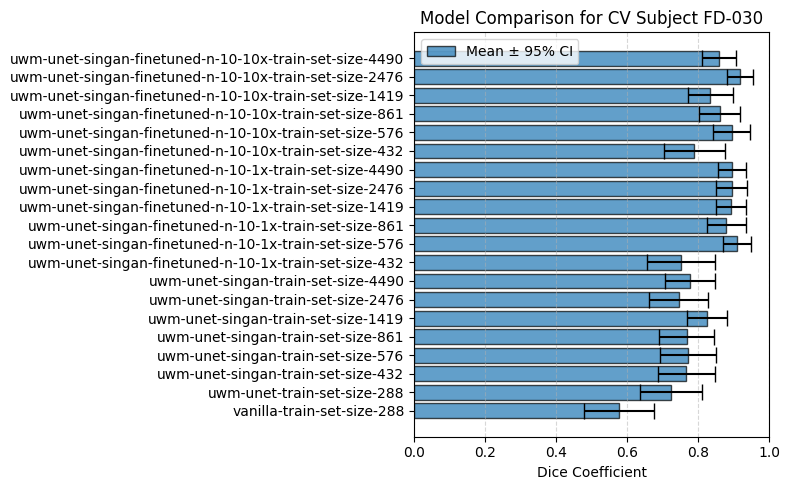

CV Subject: FD-027


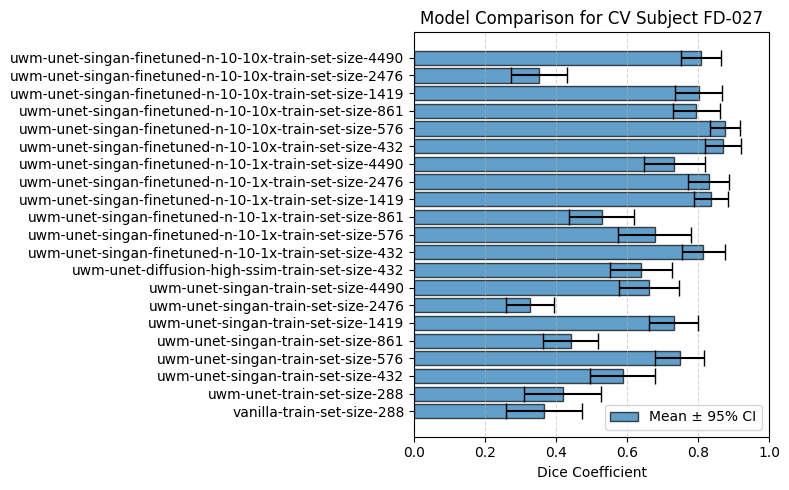

CV Subject: FD-029


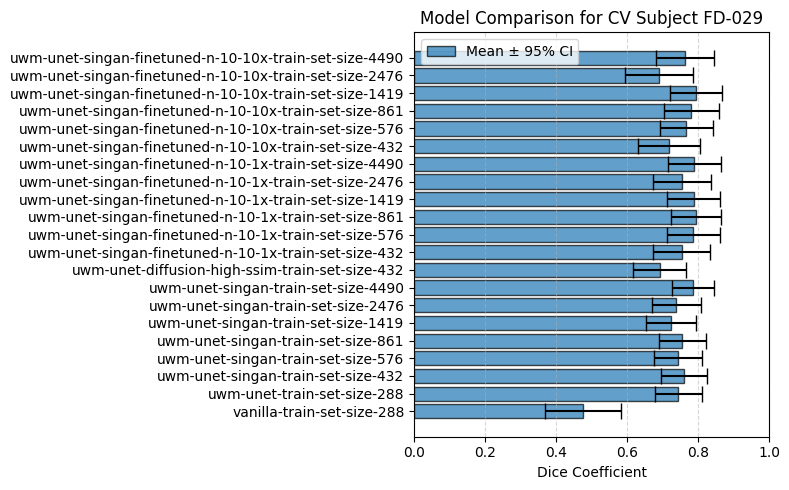

CV Subject: FD-032


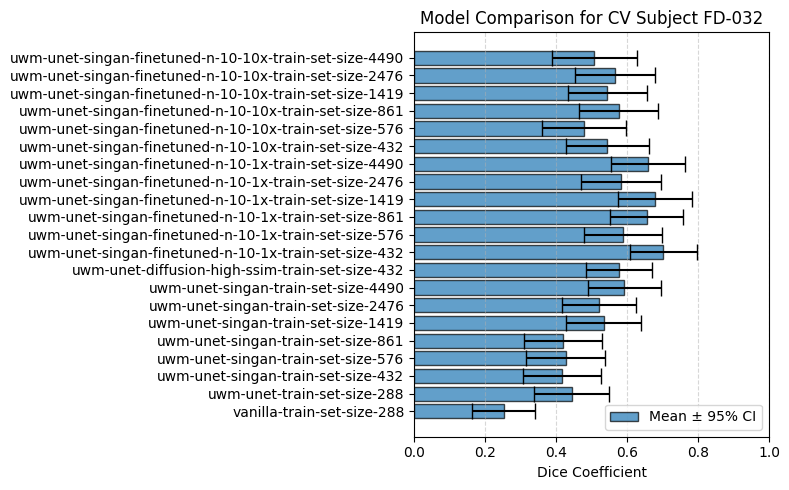

CV Subject: FD-031


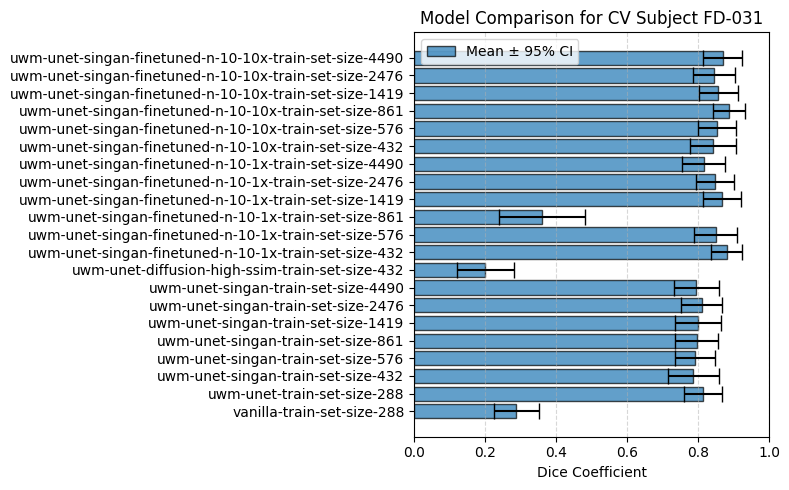

In [27]:
verbose = False
vanilla_and_uwm_unet_comparison = []

for cv_subject, data in data_per_cv_subject.items():
    print(f"CV Subject: {cv_subject}")
    dice_coefficients_all = []
    dice_coefficient_data = []

    for model_type, stats in data.items():
        dice_coefficients_all.append(stats['dice_coefficients'])
        ci_low, ci_high = scipy.stats.t.interval(
            confidence=0.95,            # 95% confidence
            df=len(stats['dice_coefficients'])-1,                # degrees of freedom
            loc=np.mean(stats['dice_coefficients']),              # sample mean
            scale=scipy.stats.sem(stats['dice_coefficients'])
        )
        dice_coefficient_data.append({
            'model_type': model_type,
            'mean_dice_coefficient': np.mean(stats['dice_coefficients']),
            'median_dice_coefficient': np.median(stats['dice_coefficients']),
            'ci_low': ci_low,
            'ci_high': ci_high,
            'dice_coefficients': stats['dice_coefficients']
        })
    
    # For each entry in dice_coefficient_data, plot it

    models = [d['model_type'] for d in dice_coefficient_data]
    means  = np.array([d['mean_dice_coefficient'] for d in dice_coefficient_data])
    medians = np.array([d['median_dice_coefficient'] for d in dice_coefficient_data])
    ci_low  = np.array([d['ci_low']  for d in dice_coefficient_data])
    ci_high = np.array([d['ci_high'] for d in dice_coefficient_data])

    # asymmetric error bars: lower = mean - ci_low, upper = ci_high - mean
    err_lower = means - ci_low
    err_upper = ci_high - means
    yerr = np.vstack([err_lower, err_upper])

    # --- make the figure ---
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(
        models,
        means,
        xerr=yerr,        # swap to horizontal error‐bars
        capsize=6,
        alpha=0.7,
        edgecolor='black',
        label='Mean ± 95% CI'
    )

    ax.set_xlabel('Dice Coefficient')
    ax.set_title(f'Model Comparison for CV Subject {cv_subject}')
    ax.set_xlim(0, 1)      # assuming dice in [0,1]
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [28]:
DISPLAYED_MODEL_NAMES = {
    'uwm-unet-train-set-size-288': 'Improved U-Net, no augmentation',
    'vanilla-train-set-size-288': 'Original U-Net',
}

In [29]:
for size in standard_train_set_sizes:
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-train-set-size-{size}'] = f'Improved U-Net, size augmented to {size}, no finetuning'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-finetuned-n-10-1x-train-set-size-{size}'] = f'Improved U-Net, size augmented to {size}, w/ finetuning'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-finetuned-n-5-1x-train-set-size-{size}'] = f'Improved U-Net, size augmented to {size}, w/ finetuning (5 imgs.)'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-finetuned-n-10-10x-train-set-size-{size}'] = f'Improved U-Net, size augmented to {size}, w/ finetuning (aug.)'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-finetuned-n-5-10x-train-set-size-{size}'] = f'Improved U-Net, size augmented to {size}, w/ finetuning (5 imgs.) (aug.)'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-ss-finetuned-ft-no-aug-train-set-size-{size}'] = f'Improved U-Net, size aug. to {size}, w/ self-supervised FT (10 imgs.)'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-singan-ss-finetuned-ft-aug-train-set-size-{size}'] = f'Improved U-Net, size aug. to {size}, w/ self-sup. FT (10 imgs.) (aug.)'


    DISPLAYED_MODEL_NAMES[f'uwm-unet-diffusion-high-ssim-train-set-size-{size}'] = f'Improved U-Net, size aug. to {size}, diffusion aug., SSIM filter'
    DISPLAYED_MODEL_NAMES[f'uwm-unet-diffusion-3-train-set-size-{size}'] = f'Improved U-Net, size aug. to {size}, diffusion aug., mask filter'


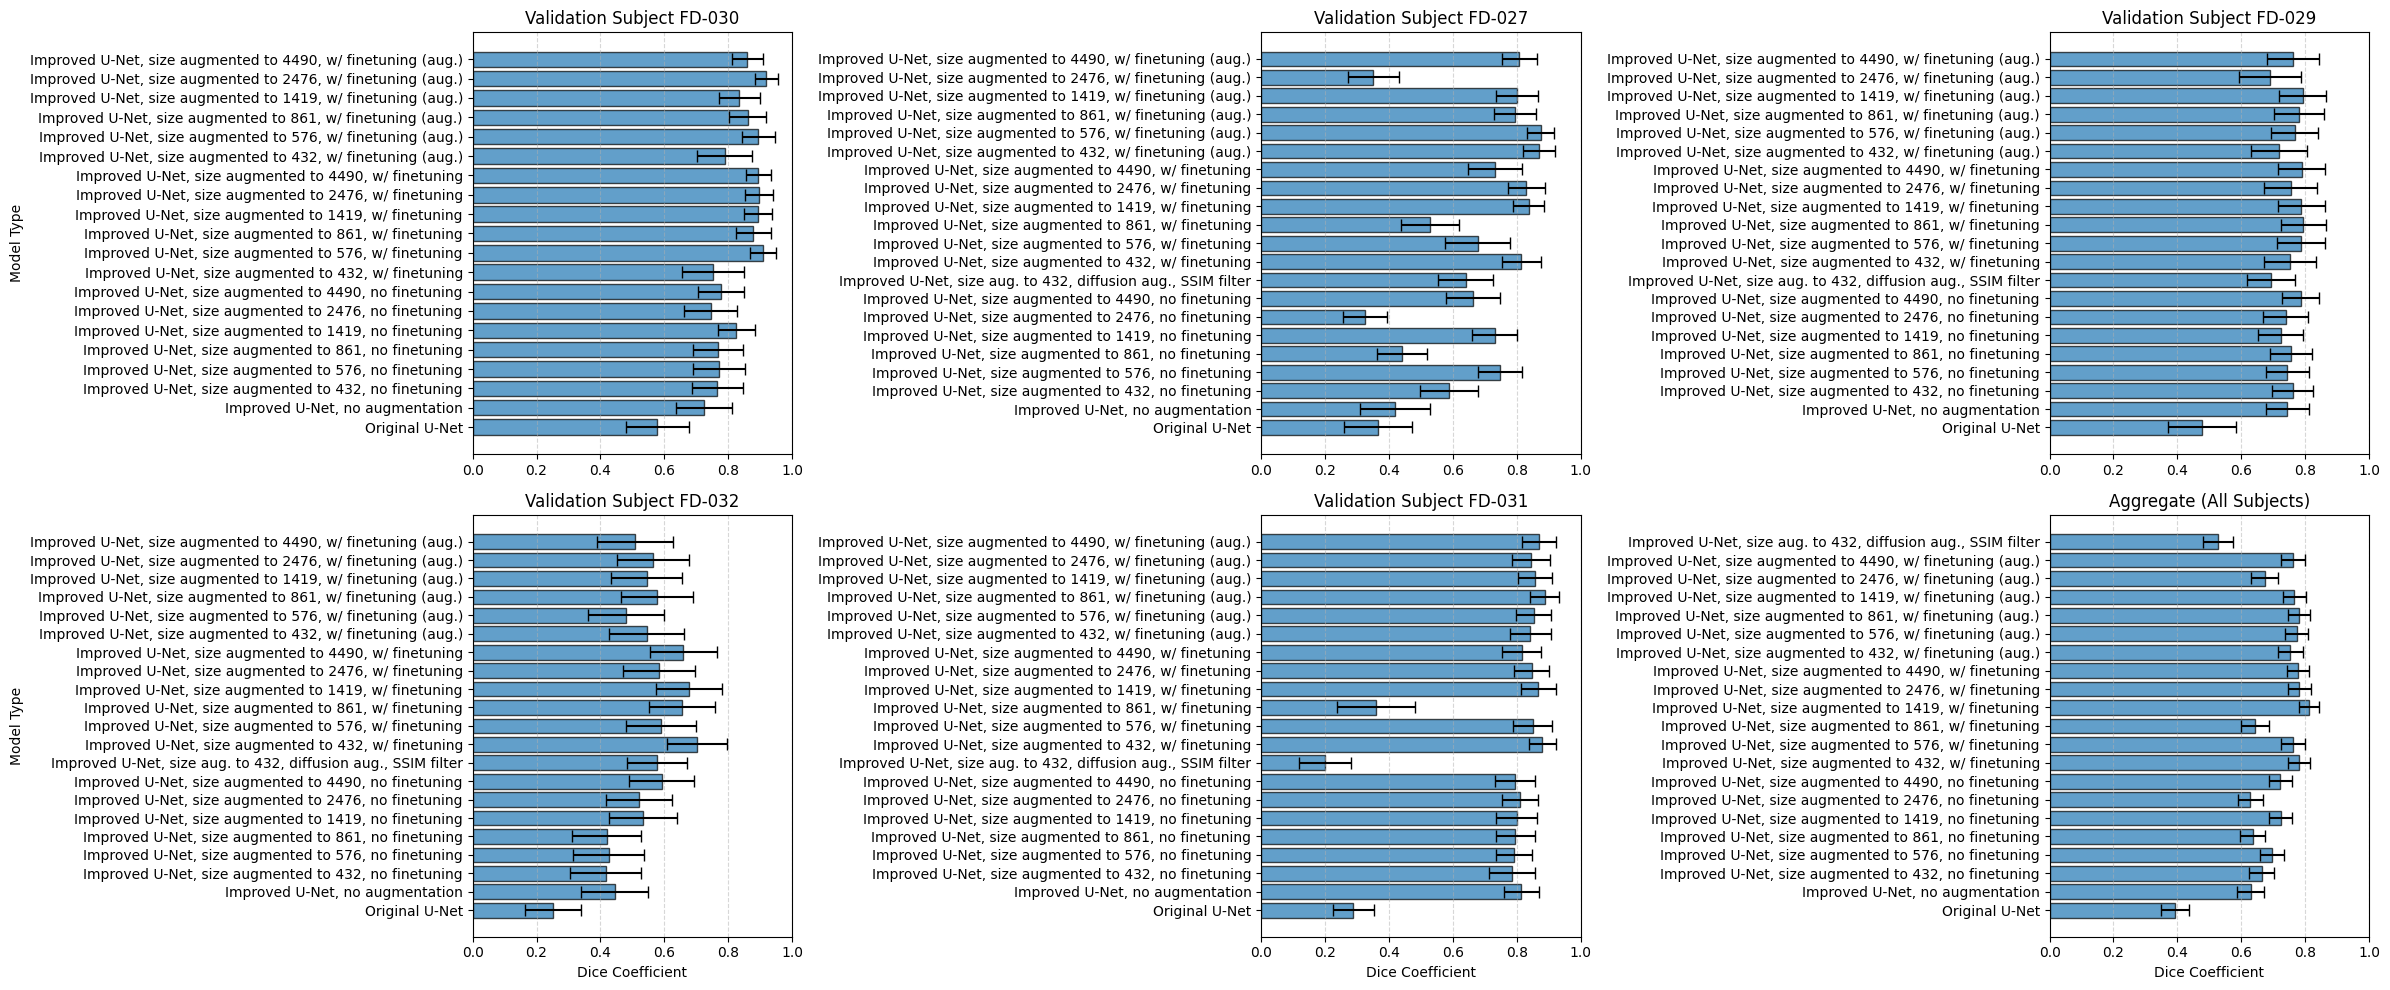

In [30]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

verbose = False
vanilla_and_uwm_unet_comparison = []

# Precompute aggregated data
combined_data = {}
for cv_subject, data in data_per_cv_subject.items():
    for model_type, stats in data.items():
        combined_data.setdefault(model_type, []).extend(stats['dice_coefficients'])

# Build aggregate dice_coefficient_data
aggregate_dice_data = []
for model_type, scores in combined_data.items():
    ci_low, ci_high = scipy.stats.t.interval(
        confidence=0.95,
        df=len(scores) - 1,
        loc=np.mean(scores),
        scale=scipy.stats.sem(scores)
    )
    aggregate_dice_data.append({
        'model_type': model_type,
        'mean_dice_coefficient': np.mean(scores),
        'ci_low': ci_low,
        'ci_high': ci_high,
        'dice_coefficients': scores
    })

# Set up 2x3 grid (assuming you have 5 CV subjects + 1 aggregate = 6 panels)
fig, axes = plt.subplots(2, 3, figsize=(24, 10))
axes = axes.flatten()

# 1) Individual CV‐subject plots
for idx, (cv_subject, data) in enumerate(data_per_cv_subject.items()):
    dice_coefficient_data = []
    for model_type, stats in data.items():
        ci_low, ci_high = scipy.stats.t.interval(
            confidence=0.95,            
            df=len(stats['dice_coefficients'])-1,
            loc=np.mean(stats['dice_coefficients']),
            scale=scipy.stats.sem(stats['dice_coefficients'])
        )
        dice_coefficient_data.append({
            'model_type': model_type,
            'mean_dice_coefficient': np.mean(stats['dice_coefficients']),
            'ci_low': ci_low,
            'ci_high': ci_high,
            'dice_coefficients': stats['dice_coefficients']
        })

    models = [DISPLAYED_MODEL_NAMES.get(d['model_type'], d['model_type']).strip() for d in dice_coefficient_data]
    means  = np.array([d['mean_dice_coefficient'] for d in dice_coefficient_data])
    ci_low  = np.array([d['ci_low']  for d in dice_coefficient_data])
    ci_high = np.array([d['ci_high'] for d in dice_coefficient_data])
    err_lower = means - ci_low
    err_upper = ci_high - means
    xerr = np.vstack([err_lower, err_upper])

    ax = axes[idx]
    ax.barh(
        models,
        means,
        xerr=xerr,
        capsize=4,
        alpha=0.7,
        edgecolor='black',
        label='Mean ± 95% CI'
    )
    ax.set_xlim(0, 1)
    ax.set_title(f'Validation Subject {cv_subject}')
    if idx % 3 == 0:
        ax.set_ylabel('Model Type')
    if idx >= 3:
        ax.set_xlabel('Dice Coefficient')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# 2) Aggregate plot in last panel
models = [DISPLAYED_MODEL_NAMES.get(d['model_type'], d['model_type']).strip() for d in aggregate_dice_data]
means  = np.array([d['mean_dice_coefficient'] for d in aggregate_dice_data])
ci_low  = np.array([d['ci_low']  for d in aggregate_dice_data])
ci_high = np.array([d['ci_high'] for d in aggregate_dice_data])
err_lower = means - ci_low
err_upper = ci_high - means
xerr = np.vstack([err_lower, err_upper])

ax = axes[-1]
ax.barh(
    models,
    means,
    xerr=xerr,
    capsize=4,
    alpha=0.7,
    edgecolor='black',
    label='Mean ± 95% CI'
)
ax.set_xlim(0, 1)
ax.set_title('Aggregate (All Subjects)')
ax.set_xlabel('Dice Coefficient')
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


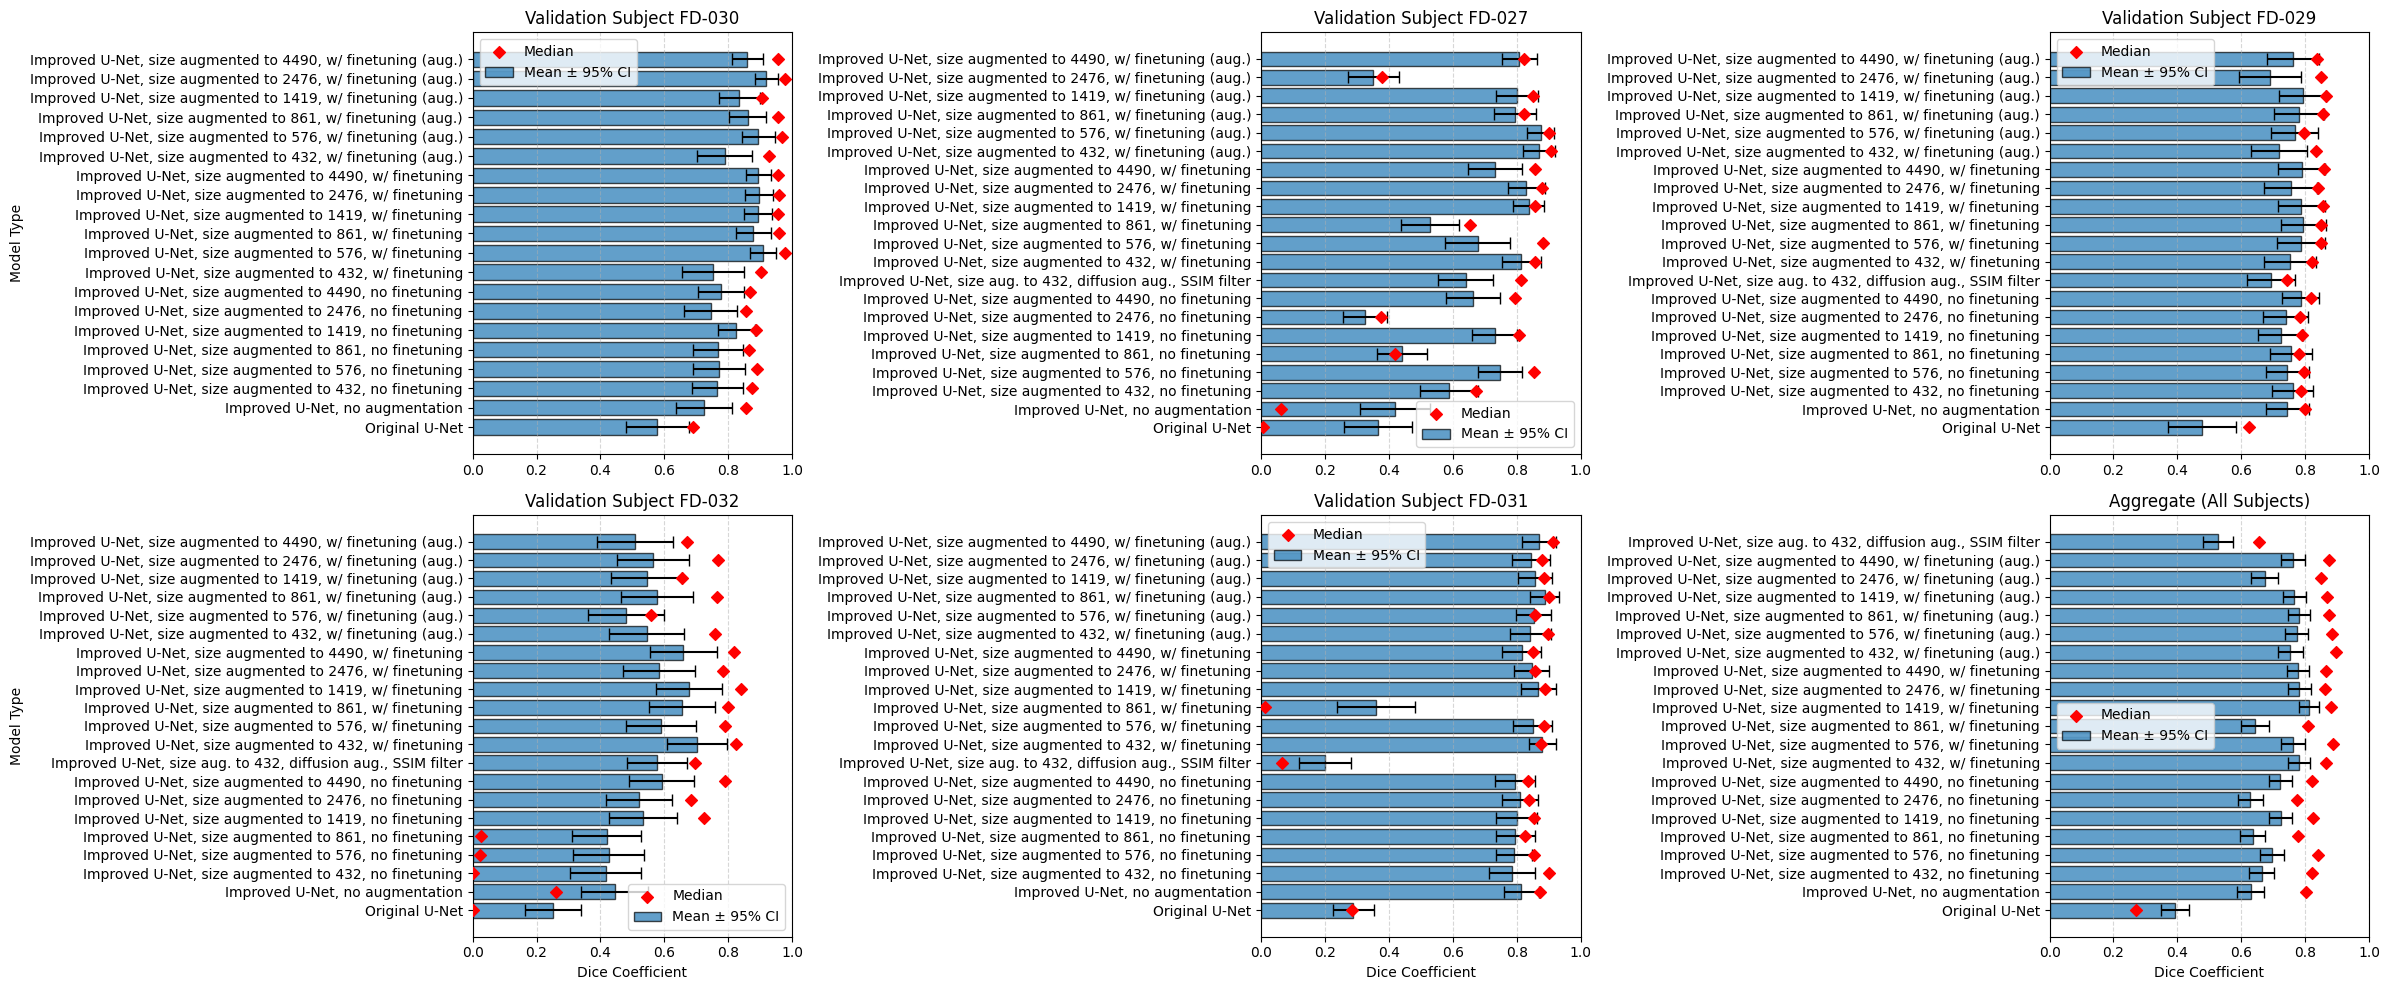

In [31]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

verbose = False
vanilla_and_uwm_unet_comparison = []

# Precompute aggregated data
combined_data = {}
for cv_subject, data in data_per_cv_subject.items():
    for model_type, stats in data.items():
        combined_data.setdefault(model_type, []).extend(stats['dice_coefficients'])

# Build aggregate dice_coefficient_data
aggregate_dice_data = []
for model_type, scores in combined_data.items():
    ci_low, ci_high = scipy.stats.t.interval(
        confidence=0.95,
        df=len(scores) - 1,
        loc=np.mean(scores),
        scale=scipy.stats.sem(scores)
    )
    aggregate_dice_data.append({
        'model_type': model_type,
        'mean_dice_coefficient': np.mean(scores),
        'median_dice_coefficient': np.median(scores),
        'ci_low': ci_low,
        'ci_high': ci_high,
        'dice_coefficients': scores
    })

# Set up 2x3 grid (assuming you have 5 CV subjects + 1 aggregate = 6 panels)
fig, axes = plt.subplots(2, 3, figsize=(24, 10))
axes = axes.flatten()

# 1) Individual CV‐subject plots
for idx, (cv_subject, data) in enumerate(data_per_cv_subject.items()):
    dice_coefficient_data = []
    for model_type, stats in data.items():
        ci_low, ci_high = scipy.stats.t.interval(
            confidence=0.95,
            df=len(stats['dice_coefficients'])-1,
            loc=np.mean(stats['dice_coefficients']),
            scale=scipy.stats.sem(stats['dice_coefficients'])
        )
        dice_coefficient_data.append({
            'model_type': model_type,
            'mean_dice_coefficient': np.mean(stats['dice_coefficients']),
            'median_dice_coefficient': np.median(stats['dice_coefficients']),
            'ci_low': ci_low,
            'ci_high': ci_high,
            'dice_coefficients': stats['dice_coefficients']
        })

    models   = [DISPLAYED_MODEL_NAMES.get(d['model_type'], d['model_type']).strip()
                for d in dice_coefficient_data]
    means    = np.array([d['mean_dice_coefficient'] for d in dice_coefficient_data])
    medians  = np.array([d['median_dice_coefficient'] for d in dice_coefficient_data])
    ci_low   = np.array([d['ci_low']  for d in dice_coefficient_data])
    ci_high  = np.array([d['ci_high'] for d in dice_coefficient_data])
    err_lower= means - ci_low
    err_upper= ci_high - means
    xerr     = np.vstack([err_lower, err_upper])

    ax = axes[idx]
    ax.barh(
        models,
        means,
        xerr=xerr,
        capsize=4,
        alpha=0.7,
        edgecolor='black',
        label='Mean ± 95% CI'
    )
    # overlay medians as red diamonds
    ax.scatter(
        medians,
        models,
        marker='D',
        color='red',
        label='Median',
        zorder=5
    )

    ax.set_xlim(0, 1)
    ax.set_title(f'Validation Subject {cv_subject}')
    if idx % 3 == 0:
        ax.set_ylabel('Model Type')
    if idx >= 3:
        ax.set_xlabel('Dice Coefficient')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend()

# 2) Aggregate plot in last panel
models   = [DISPLAYED_MODEL_NAMES.get(d['model_type'], d['model_type']).strip()
            for d in aggregate_dice_data]
means    = np.array([d['mean_dice_coefficient']   for d in aggregate_dice_data])
medians  = np.array([d['median_dice_coefficient'] for d in aggregate_dice_data])
ci_low   = np.array([d['ci_low']   for d in aggregate_dice_data])
ci_high  = np.array([d['ci_high']  for d in aggregate_dice_data])
err_lower= means - ci_low
err_upper= ci_high - means
xerr     = np.vstack([err_lower, err_upper])

ax = axes[-1]
ax.barh(
    models,
    means,
    xerr=xerr,
    capsize=4,
    alpha=0.7,
    edgecolor='black',
    label='Mean ± 95% CI'
)
# overlay aggregate medians
ax.scatter(
    medians,
    models,
    marker='D',
    color='red',
    label='Median',
    zorder=5
)

ax.set_xlim(0, 1)
ax.set_title('Aggregate (All Subjects)')
ax.set_xlabel('Dice Coefficient')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()


In [35]:
rows

{'FD-030_means': {'Original U-Net': 0.5779418090081774,
  'Improved U-Net, no augmentation': 0.72482474202788,
  'Improved U-Net, size augmented to 432, no finetuning': 0.7662984304336404,
  'Improved U-Net, size augmented to 576, no finetuning': 0.7715480869697142,
  'Improved U-Net, size augmented to 861, no finetuning': 0.7680394007790284,
  'Improved U-Net, size augmented to 1419, no finetuning': 0.8258011325041907,
  'Improved U-Net, size augmented to 2476, no finetuning': 0.7449330362965729,
  'Improved U-Net, size augmented to 4490, no finetuning': 0.7773445824856672,
  'Improved U-Net, size augmented to 432, w/ finetuning': 0.7520494559273437,
  'Improved U-Net, size augmented to 576, w/ finetuning': 0.909875357401743,
  'Improved U-Net, size augmented to 861, w/ finetuning': 0.8792827457545819,
  'Improved U-Net, size augmented to 1419, w/ finetuning': 0.8932419112236144,
  'Improved U-Net, size augmented to 2476, w/ finetuning': 0.8955820953276724,
  'Improved U-Net, size aug

In [38]:
rows = {}

all_scores = {}

for cv_subject, data in data_per_cv_subject.items():
    row_means = {}
    row_medians = {}

    for model_type, stats in data.items():
        scores = np.array(stats['dice_coefficients'])
        all_scores[model_type] = scores if model_type not in all_scores else np.concatenate((all_scores[model_type], scores))
        mean   = scores.mean()
        median = np.median(scores)
        row_means[DISPLAYED_MODEL_NAMES[model_type]] = mean
        row_medians[DISPLAYED_MODEL_NAMES[model_type]] = median
    rows[f'{cv_subject}_means'] = row_means
    rows[f'{cv_subject}_medians'] = row_medians

In [41]:
all_means   = {}
all_medians = {}
for model_type, scores in all_scores.items():
    name = DISPLAYED_MODEL_NAMES[model_type]
    all_means[name]   = scores.mean()
    all_medians[name] = np.median(scores)

rows['all_means']   = all_means
rows['all_medians'] = all_medians

In [42]:

pd.DataFrame(rows).to_csv('tmp_output/model_average_dice_coefficients.csv')

In [256]:
import re
import random
import matplotlib.colors as mcolors

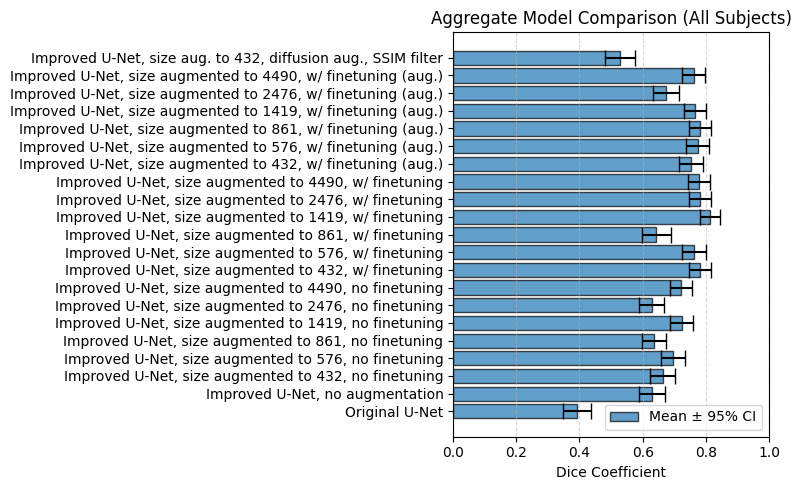

In [257]:
# 1) Aggregate all dice‐coefficients per model across every CV subject
combined_data = {}
for cv_subject, data in data_per_cv_subject.items():
    for model_type, stats in data.items():
        combined_data.setdefault(model_type, []).extend(stats['dice_coefficients'])

# 2) Build the same dice_coefficient_data list you had inside your loop
dice_coefficient_data = []
for model_type, scores in combined_data.items():
    ci_low, ci_high = scipy.stats.t.interval(
        confidence=0.95,
        df=len(scores) - 1,
        loc=np.mean(scores),
        scale=scipy.stats.sem(scores)
    )
    dice_coefficient_data.append({
        'model_type': model_type,
        'mean_dice_coefficient': np.mean(scores),
        'ci_low': ci_low,
        'ci_high': ci_high,
        'dice_coefficients': scores
    })

# 3) Prepare plotting arrays
models   = [DISPLAYED_MODEL_NAMES.get(d['model_type'], d['model_type']).strip() for d in dice_coefficient_data]

model_categories = []
for model in models:
    displayed_label = DISPLAYED_MODEL_NAMES.get(model, model).strip()
    cleaned_label = re.sub(r"size augmented to \d+,\s*", "", displayed_label)
    cleaned_label = re.sub(r"size aug. to \d+,\s*", "", cleaned_label)
    model_categories.append(cleaned_label)

# 1) find the unique categories (in order)
unique_cats = list(dict.fromkeys(model_categories))

# 2) assign each one a random RGB tuple, then convert to hex
color_map = {
    cat: mcolors.to_hex((random.random(), random.random(), random.random()))
    for cat in unique_cats
}

# 3) build your final array of colors
colors = [color_map[cat] for cat in model_categories]

means    = np.array([d['mean_dice_coefficient'] for d in dice_coefficient_data])
ci_low   = np.array([d['ci_low']  for d in dice_coefficient_data])
ci_high  = np.array([d['ci_high'] for d in dice_coefficient_data])

# asymmetric error bars: lower = mean - ci_low, upper = ci_high - mean
err_lower = means - ci_low
err_upper = ci_high - means
yerr      = np.vstack([err_lower, err_upper])

# 4) Plot exactly like before, but now aggregate
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    models,
    means,
    xerr=yerr,        # horizontal error‐bars
    capsize=6,
    alpha=0.7,
    edgecolor='black',
    label='Mean ± 95% CI'
)

ax.set_xlabel('Dice Coefficient')
ax.set_title('Aggregate Model Comparison (All Subjects)')
ax.set_xlim(0, 1)      # assuming dice in [0,1]
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2106449/3985219224.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


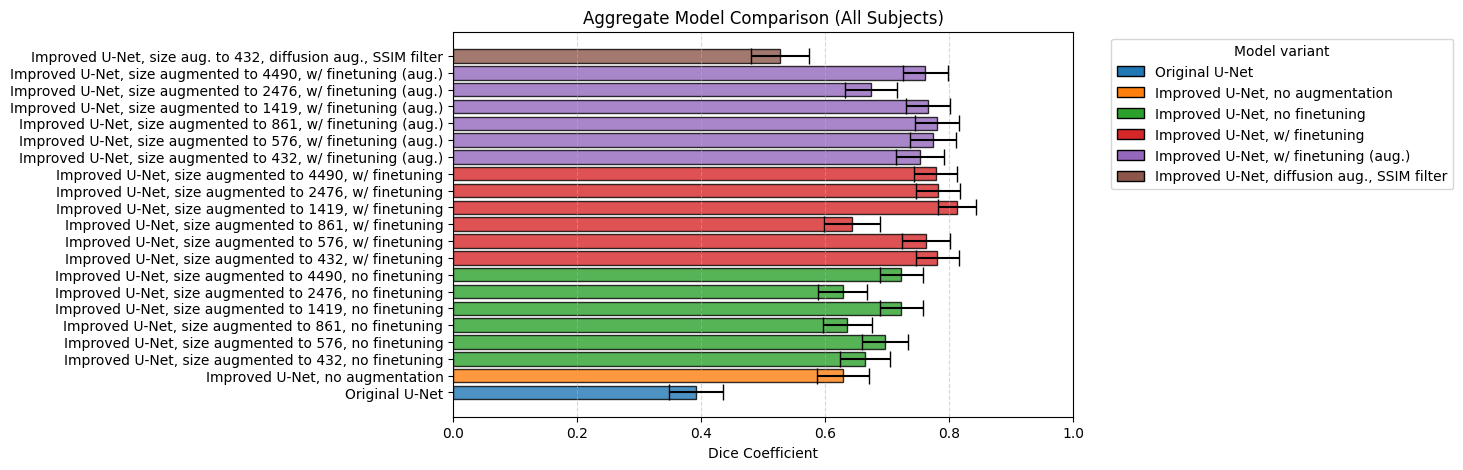

In [258]:
import matplotlib.pyplot as plt

# … after you’ve computed:
#    models           = [...]
#    means            = np.array([...])
#    yerr             = np.vstack([…, …])
#    model_categories = [...]   # e.g. ["Improved U-Net, no finetuning", "Improved U-Net, w/ finetuning", …]

# 1) get Matplotlib's default color cycle
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 2) assign each unique category one of those colors
unique_cats = list(dict.fromkeys(model_categories))
color_map = {
    cat: default_colors[i % len(default_colors)]
    for i, cat in enumerate(unique_cats)
}

# 3) build the color list aligned with your bars
colors = [color_map[cat] for cat in model_categories]

# 4) plot, passing in your per-bar colors
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    models,
    means,
    xerr=yerr,
    capsize=6,
    edgecolor='black',
    alpha=0.8,
    color=colors,            # ← here
)

ax.set_xlabel('Dice Coefficient')
ax.set_title('Aggregate Model Comparison (All Subjects)')
ax.set_xlim(0, 1)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# 5) build a legend from those same colors
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=color_map[cat], edgecolor='black', label=cat)
    for cat in unique_cats
]
ax.legend(
    handles=legend_handles,
    title='Model variant',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2106449/1434689155.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


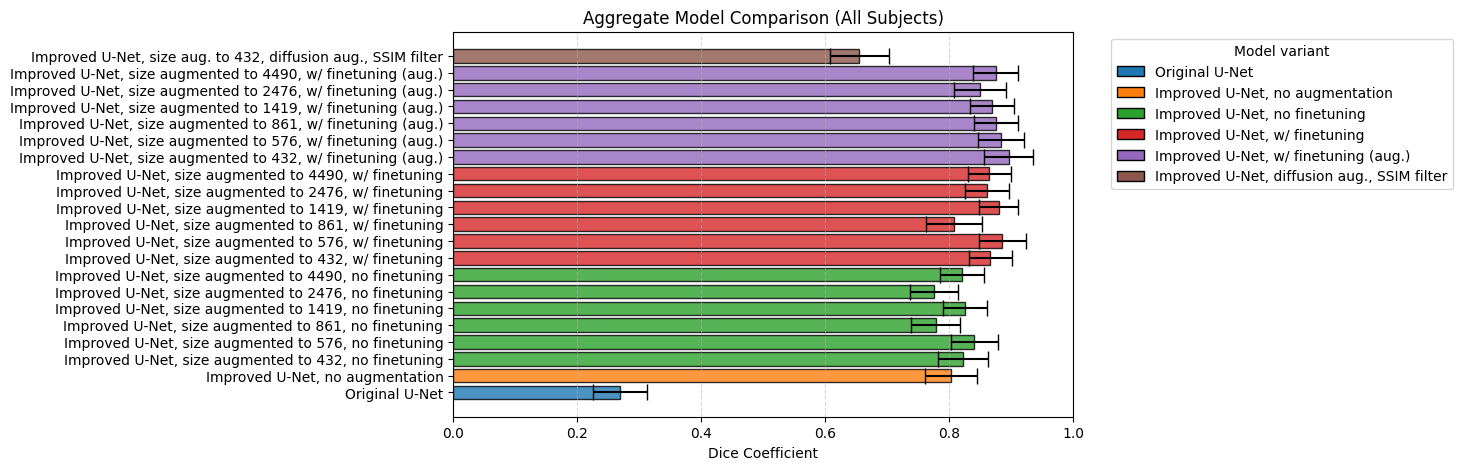

In [259]:
import matplotlib.pyplot as plt

# … after you’ve computed:
#    models           = [...]
#    means            = np.array([...])
#    yerr             = np.vstack([…, …])
#    model_categories = [...]   # e.g. ["Improved U-Net, no finetuning", "Improved U-Net, w/ finetuning", …]

# 1) get Matplotlib's default color cycle
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 2) assign each unique category one of those colors
unique_cats = list(dict.fromkeys(model_categories))
color_map = {
    cat: default_colors[i % len(default_colors)]
    for i, cat in enumerate(unique_cats)
}

# 3) build the color list aligned with your bars
colors = [color_map[cat] for cat in model_categories]

# 4) plot, passing in your per-bar colors
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    models,
    medians,
    xerr=yerr,
    capsize=6,
    edgecolor='black',
    alpha=0.8,
    color=colors,            # ← here
)

ax.set_xlabel('Dice Coefficient')
ax.set_title('Aggregate Model Comparison (All Subjects)')
ax.set_xlim(0, 1)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# 5) build a legend from those same colors
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=color_map[cat], edgecolor='black', label=cat)
    for cat in unique_cats
]
ax.legend(
    handles=legend_handles,
    title='Model variant',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


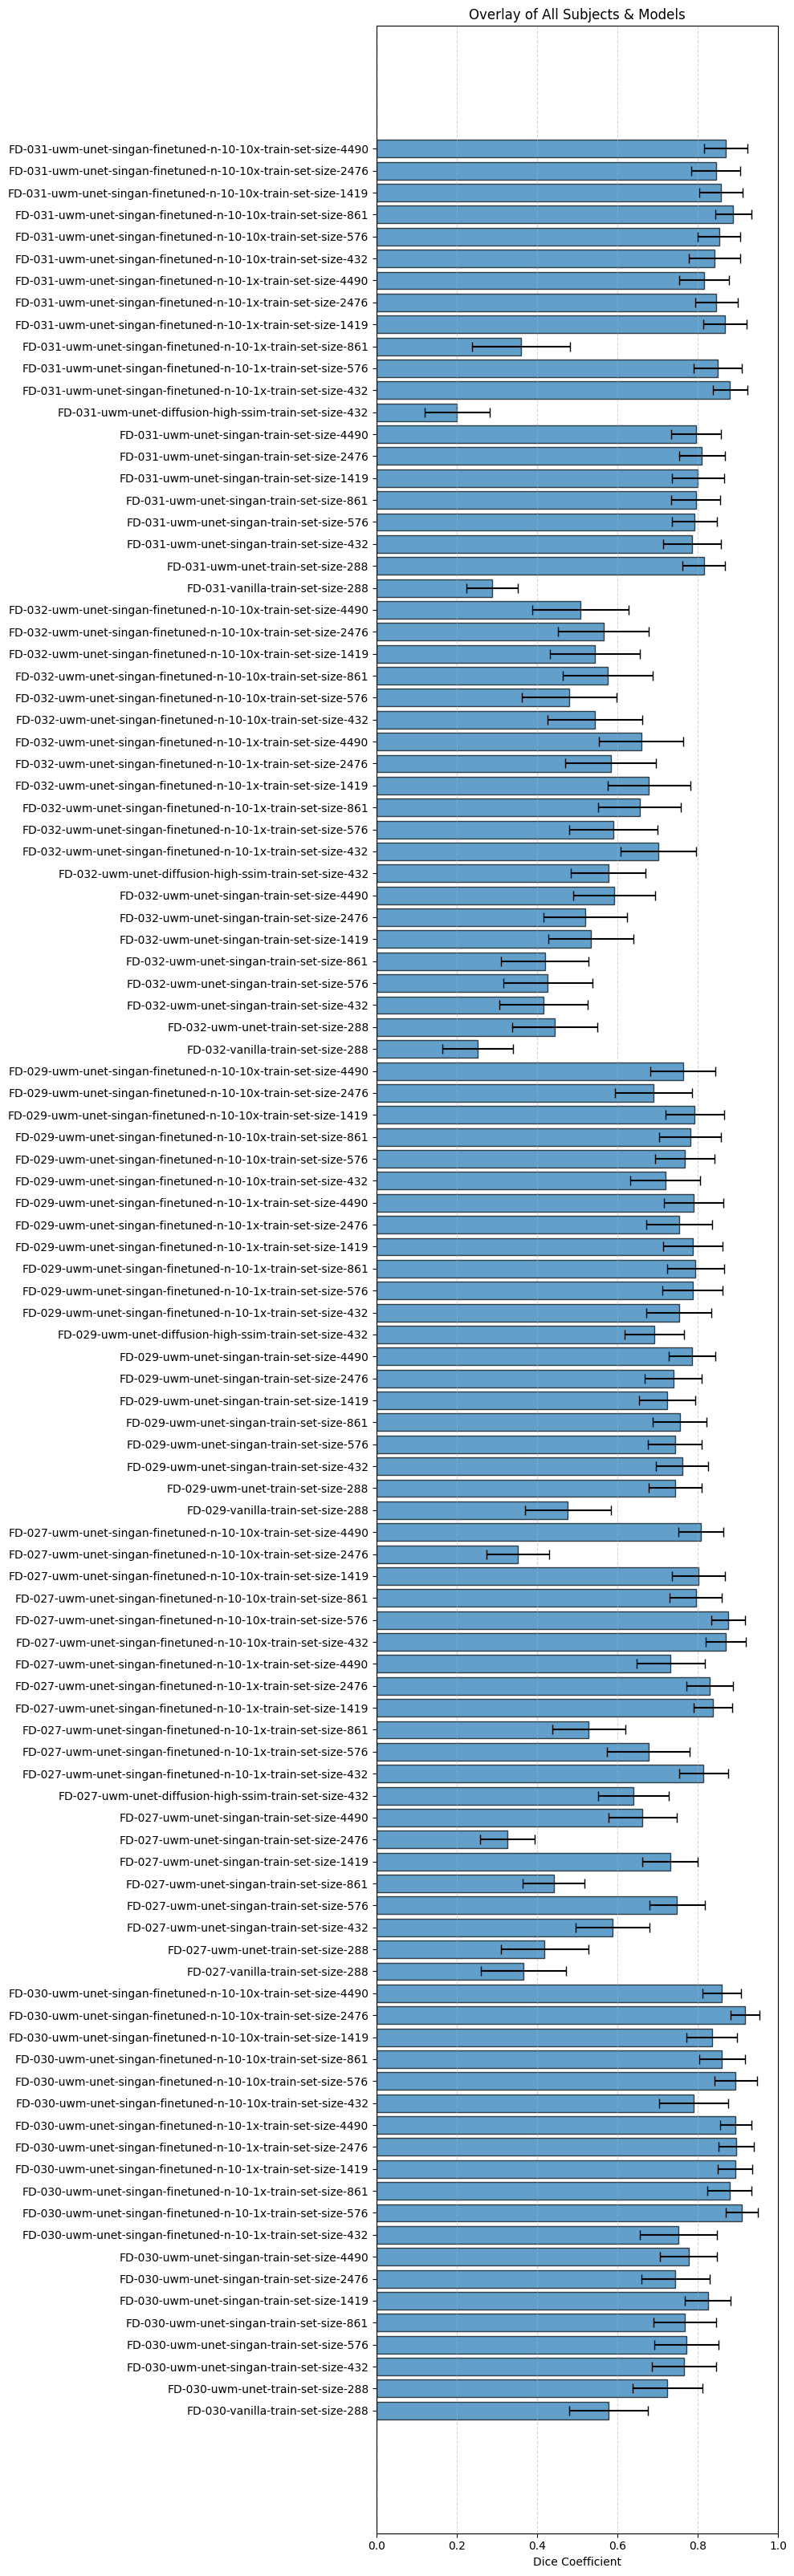

In [260]:
# 1) Gather everything into flat lists
combined_labels    = []
combined_means     = []
combined_ci_low    = []
combined_ci_high   = []

for cv_subject, data in data_per_cv_subject.items():
    for model_type, stats in data.items():
        scores = np.array(stats['dice_coefficients'])
        mean   = scores.mean()
        sem    = scipy.stats.sem(scores)
        ci_low, ci_high = scipy.stats.t.interval(
            confidence=0.95,
            df=len(scores)-1,
            loc=mean,
            scale=sem
        )
        combined_labels.append(f"{cv_subject}-{model_type}")
        combined_means.append(mean)
        combined_ci_low.append(ci_low)
        combined_ci_high.append(ci_high)

# 2) Compute asymmetric error‐bars
means_arr   = np.array(combined_means)
err_lower   = means_arr - np.array(combined_ci_low)
err_upper   = np.array(combined_ci_high) - means_arr
xerr        = np.vstack([err_lower, err_upper])

# 3) Single overlaid horizontal bar chart
fig, ax = plt.subplots(figsize=(10, len(combined_labels) * 0.3 + 1))
bars = ax.barh(
    combined_labels,
    combined_means,
    xerr=xerr,
    capsize=4,
    alpha=0.7,
    edgecolor='black',
    label='Mean ± 95% CI'
)

ax.set_xlabel('Dice Coefficient')
ax.set_title('Overlay of All Subjects & Models')
ax.set_xlim(0, 1)  
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [267]:
rows = {}
for cv_subject, data in data_per_cv_subject.items():
    row_means = {}
    row_medians = {}
    for model_type, stats in data.items():
        scores = np.array(stats['dice_coefficients'])
        mean   = scores.mean()
        median = np.median(scores)
        row_means[DISPLAYED_MODEL_NAMES[model_type]] = mean
        row_medians[DISPLAYED_MODEL_NAMES[model_type]] = median
    rows[f'{cv_subject}_means'] = row_means
    rows[f'{cv_subject}_medians'] = row_medians


In [268]:
pd.DataFrame(rows).to_csv('tmp_output/model_average_dice_coefficients.csv')

In [269]:
row

{'Original U-Net_mean': 0.2881427017330936,
 'Original U-Net_median': 0.2844911217689514,
 'Improved U-Net, no augmentation_mean': 0.8152006836686552,
 'Improved U-Net, no augmentation_median': 0.8736253380775452,
 'Improved U-Net, size augmented to 432, no finetuning_mean': 0.7863513829924155,
 'Improved U-Net, size augmented to 432, no finetuning_median': 0.9020046889781952,
 'Improved U-Net, size augmented to 576, no finetuning_mean': 0.7912624435991731,
 'Improved U-Net, size augmented to 576, no finetuning_median': 0.8558704555034637,
 'Improved U-Net, size augmented to 861, no finetuning_mean': 0.7956704159495255,
 'Improved U-Net, size augmented to 861, no finetuning_median': 0.8252704441547394,
 'Improved U-Net, size augmented to 1419, no finetuning_mean': 0.8004591818402562,
 'Improved U-Net, size augmented to 1419, no finetuning_median': 0.854271799325943,
 'Improved U-Net, size augmented to 2476, no finetuning_mean': 0.8108053672463822,
 'Improved U-Net, size augmented to 24

In [42]:
f_score_dfs = {}
p_value_dfs = {}

for cv_subject, data in data_per_cv_subject.items():
    f_score_data = {}
    p_value_data = {}
    for model_type_a, stats_model_a in data.items():
        f_scores_a = {}
        p_values_a = {}

        scores_model_a = np.array(stats_model_a['dice_coefficients'])
        for model_type_b, stats_model_b in data.items():
            if model_type_a == model_type_b:
                continue
            scores_model_b = np.array(stats_model_b['dice_coefficients'])

                

            f_score, p_value = scipy.stats.f_oneway(scores_model_a, scores_model_b)
            f_scores_a[model_type_b] = f_score

            if (np.mean(scores_model_a) > np.mean(scores_model_b)):
                p_value *= -1
            
            p_values_a[model_type_b] = p_value
        
        f_score_data[model_type_a] = f_scores_a
        p_value_data[model_type_a] = p_values_a
    
    f_score_df = pd.DataFrame(f_score_data).T
    p_value_df = pd.DataFrame(p_value_data).T

    f_score_dfs[cv_subject] = f_score_df
    p_value_dfs[cv_subject] = p_value_df

In [43]:
import pandas as pd

# where to write
outfile = 'tmp_output/combined_cv_results.xlsx'

with pd.ExcelWriter(outfile) as writer:
    # write all of the f‐score DataFrames
    for cv_subject, f_df in f_score_dfs.items():
        sheet = f"{cv_subject}_F"[:31]               # Excel sheet names max 31 chars
        f_df.to_excel(writer, sheet_name=sheet, index=True)
    # write all of the p‐value DataFrames
    for cv_subject, p_df in p_value_dfs.items():
        sheet = f"{cv_subject}_P"[:31]
        p_df.to_excel(writer, sheet_name=sheet, index=True)

In [44]:
import numpy as np
import pandas as pd
import scipy.stats

# 1) Aggregate all dice‐coefficients per model across every CV subject
agg_scores = {}
for data in data_per_cv_subject.values():
    for model_type, stats in data.items():
        agg_scores.setdefault(model_type, []).extend(stats['dice_coefficients'])

# 2) Run pairwise one‐way ANOVA on the aggregated lists
models = list(agg_scores)
agg_f_scores  = {}
agg_p_values  = {}

for model_a in models:
    agg_f_scores[DISPLAYED_MODEL_NAMES[model_a]] = {}
    agg_p_values[DISPLAYED_MODEL_NAMES[model_a]] = {}
    scores_a = np.array(agg_scores[model_a])
    for model_b in models:
        if model_a == model_b:
            continue
        scores_b = np.array(agg_scores[model_b])
        f, p = scipy.stats.f_oneway(scores_a, scores_b)

        if (np.mean(scores_a) > np.mean(scores_b)):
            p *= -1

        agg_f_scores[DISPLAYED_MODEL_NAMES[model_a]][DISPLAYED_MODEL_NAMES[model_b]] = f
        agg_p_values[DISPLAYED_MODEL_NAMES[model_a]][DISPLAYED_MODEL_NAMES[model_b]] = p

# 3) Turn these into DataFrames (transpose to match your existing style)
aggregated_f_score_df = pd.DataFrame(agg_f_scores).T
aggregated_p_value_df = pd.DataFrame(agg_p_values).T

# 4) (Optional) inspect or save to Excel/CSV
print("Aggregate F-scores:")
print(aggregated_f_score_df)

print("\nAggregate p-values:")
print(aggregated_p_value_df)

aggregated_f_score_df.to_csv('tmp_output/aggregated_f_scores.csv', index=True)
aggregated_p_value_df.to_csv('tmp_output/aggregated_p_values.csv', index=True)


Aggregate F-scores:
                                                    Improved U-Net, no augmentation  \
Original U-Net                                                            60.235200   
Improved U-Net, no augmentation                                                 NaN   
Improved U-Net, size augmented to 432, no finet...                         1.341984   
Improved U-Net, size aug. to 432, diffusion aug...                        10.147962   
Improved U-Net, size aug. to 432, diffusion aug...                         0.570104   

                                                    Improved U-Net, size augmented to 432, no finetuning  \
Original U-Net                                                                              81.950568      
Improved U-Net, no augmentation                                                              1.341984      
Improved U-Net, size augmented to 432, no finet...                                                NaN      
Improved U-Net, size aug.

In [45]:
for cv_subject, f_score_df in f_score_dfs.items():
    print(f"CV Subject: {cv_subject}")
    print(f_score_df)
    f_score_df.to_csv('tmp_output/f_score_output/f_score_df_' + cv_subject + '.csv')
for cv_subject, p_value_df in p_value_dfs.items():
    print(f"CV Subject: {cv_subject}")
    print(p_value_df)
    p_value_df.to_csv('tmp_output/p_score_output/p_value_df_' + cv_subject + '.csv')

CV Subject: FD-030
                                    uwm-unet-train-set-size-288  \
vanilla-train-set-size-288                             4.957451   
uwm-unet-train-set-size-288                                 NaN   
uwm-unet-singan-train-set-size-432                     0.484457   

                                    uwm-unet-singan-train-set-size-432  \
vanilla-train-set-size-288                                    8.726671   
uwm-unet-train-set-size-288                                   0.484457   
uwm-unet-singan-train-set-size-432                                 NaN   

                                    vanilla-train-set-size-288  
vanilla-train-set-size-288                                 NaN  
uwm-unet-train-set-size-288                           4.957451  
uwm-unet-singan-train-set-size-432                    8.726671  
CV Subject: FD-027
                                                 uwm-unet-train-set-size-288  \
vanilla-train-set-size-288                              

In [46]:
verbose = False
dice_coefficient_data = []
for cv_subject, data in data_per_cv_subject.items():
    print(f"CV Subject: {cv_subject}")
    dice_coefficients_all = []

    images_and_ssim_mse_values_cv_subject = []

    for model_type, stats in data.items():
        dice_coefficients_all.append(stats['dice_coefficients'])
        dice_coefficient_data.append({
            'cv_subject': cv_subject,
            'model_type': model_type,
            'mean_dice_coefficient': np.mean(stats['dice_coefficients']),
        })

        

CV Subject: FD-030
CV Subject: FD-027
CV Subject: FD-029
CV Subject: FD-032
CV Subject: FD-031


In [47]:
dice_coefficient_data_df = pd.DataFrame(dice_coefficient_data)

In [48]:
import numpy as np
import scipy.stats as st
import pandas as pd

# 1. Build a dict of all dice coefficients per model, across every CV subject
model_dice = {}
for subject_stats in data_per_cv_subject.values():
    for model_type, stats in subject_stats.items():
        model_dice.setdefault(DISPLAYED_MODEL_NAMES.get(model_type, model_type).strip(), []).extend(stats['dice_coefficients'])

# 2. Compute aggregate metrics per model
agg_results = []
for model_type, dice_list in model_dice.items():
    mean_dc = np.mean(dice_list)
    agg_results.append({
        'model_type': model_type,
        'n_samples': len(dice_list),
        'mean_dice_coefficient': mean_dc,
    })

agg_df = pd.DataFrame(agg_results)

In [49]:
agg_df

,model_type,n_samples,mean_dice_coefficient
0,Original U-Net,360,0.391986
1,"Improved U-Net, no augmentation",360,0.629464
2,"Improved U-Net, size augmented to 432, no fine...",360,0.663674
3,"Improved U-Net, size aug. to 432, diffusion au...",288,0.527462
4,"Improved U-Net, size aug. to 432, diffusion au...",288,0.652653


In [50]:
dice_coefficient_data_df.to_csv('tmp_output/dice_coefficient_data.csv', index=False)

In [51]:
agg_df.to_csv('tmp_output/agg_dice_coefficient_data.csv', index=False)

In [52]:
pd.DataFrame(vanilla_and_uwm_unet_comparison).to_csv('tmp_output/vanilla_and_uwm_unet_comparison.csv')

In [53]:
images_and_ssim_mse_values = pd.DataFrame(images_and_ssim_mse_values)

In [54]:
images_and_ssim_mse_values

,original_image_path,original_mask_path,predicted_mask_path,dice_value,cv_subject,model_type,filename
0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,8.000855e-01,FD-030,vanilla-train-set-size-288,FD-030-slice-39-original_image.png
1,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,3.072197e-10,FD-030,vanilla-train-set-size-288,FD-030-slice-29-original_image.png
2,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,9.285051e-10,FD-030,vanilla-train-set-size-288,FD-030-slice-65-original_image.png
3,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,1.000000e+00,FD-030,vanilla-train-set-size-288,FD-030-slice-08-original_image.png
4,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,1.000000e+00,FD-030,vanilla-train-set-size-288,FD-030-slice-17-original_image.png
...,...,...,...,...,...,...,...
1651,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,9.197940e-11,FD-031,uwm-unet-diffusion-3-train-set-size-432,FD-031-slice-72-original_image.png
1652,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,1.000000e+00,FD-031,uwm-unet-diffusion-3-train-set-size-432,FD-031-slice-03-original_image.png
1653,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,3.528858e-01,FD-031,uwm-unet-diffusion-3-train-set-size-432,FD-031-slice-23-original_image.png
1654,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,9.402673e-01,FD-031,uwm-unet-diffusion-3-train-set-size-432,FD-031-slice-41-original_image.png


In [55]:
image_performance_data = []
for filename in images_and_ssim_mse_values['filename'].unique():
    filename_data = images_and_ssim_mse_values[images_and_ssim_mse_values['filename'] == filename]
    row_data = {
        'filename': filename
    }
    for i in filename_data.index:
        for model_type in filename_data['model_type'].unique():
            model_type_data = filename_data[filename_data['model_type'] == model_type]
            model_type_data = model_type_data.loc[model_type_data.index[0]]

            row_data[model_type] = model_type_data['dice_value']
    image_performance_data.append(row_data)

In [56]:
image_performance_data_df = pd.DataFrame(image_performance_data)

In [57]:
print('Model types:', image_performance_data_df.columns[1:].values.tolist())

Model types: ['vanilla-train-set-size-288', 'uwm-unet-train-set-size-288', 'uwm-unet-singan-train-set-size-432', 'uwm-unet-diffusion-high-ssim-train-set-size-432', 'uwm-unet-diffusion-3-train-set-size-432']


In [58]:
model_types

['vanilla-train-set-size-288',
 'uwm-unet-train-set-size-288',
 'uwm-unet-singan-train-set-size-432',
 'uwm-unet-diffusion-high-ssim-train-set-size-432',
 'uwm-unet-diffusion-3-train-set-size-432']

In [59]:
model_1 = 'uwm-unet-train-set-size-288'
model_2 = 'uwm-unet-singan-train-set-size-1419'
good_threshold = 0.5

bad_threshold = 0.2
export_folder = f'tmp_output/{model_1}_{model_2}_comparison/'

comparative_results = {
    'both_good': image_performance_data_df[(image_performance_data_df[model_1] > good_threshold) & (image_performance_data_df[model_2] > good_threshold)],
    'both_bad': image_performance_data_df[(image_performance_data_df[model_1] < bad_threshold) & (image_performance_data_df[model_2] < bad_threshold)],
    'model_1_good_model_2_bad': image_performance_data_df[(image_performance_data_df[model_1] > good_threshold) & (image_performance_data_df[model_2] < bad_threshold)],
    'model_1_bad_model_2_good': image_performance_data_df[(image_performance_data_df[model_1] < bad_threshold) & (image_performance_data_df[model_2] > good_threshold)]
}

for key, value in tqdm(list(comparative_results.items())[::-1]):
    export_subfolder_path = os.path.join(export_folder, key)
    if os.path.exists(export_subfolder_path):
        shutil.rmtree(export_subfolder_path)

    os.makedirs(export_subfolder_path, exist_ok=True)
    for i in tqdm(value.index):
        filename = value.loc[i, 'filename']
        filename_data = images_and_ssim_mse_values[images_and_ssim_mse_values['filename'] == filename]

        original_image = helpers.load_image_normalized(filename_data['original_image_path'].values[0])
        original_mask = helpers.load_image_normalized(filename_data['original_mask_path'].values[0])

        model_1_filename_data = filename_data[filename_data['model_type'] == model_1]
        model_1_predicted_mask = helpers.load_image_normalized(model_1_filename_data['predicted_mask_path'].values[0])

        model_2_filename_data = filename_data[filename_data['model_type'] == model_2]
        model_2_predicted_mask = helpers.load_image_normalized(model_2_filename_data['predicted_mask_path'].values[0])

        model_1_dice_value = value.loc[i, model_1]
        model_2_dice_value = value.loc[i, model_2]

        output_path = os.path.join(export_subfolder_path, f"{filename}")

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.subplots_adjust(top=0.85)

        # turn masks into 2D booleans
        if original_mask.ndim == 3:
            gt_bin = original_mask[..., 0] > 0.5
        else:
            gt_bin = original_mask > 0.5

        if model_1_predicted_mask.ndim == 3:
            m1_bin = model_1_predicted_mask[..., 0] > 0.5
        else:
            m1_bin = model_1_predicted_mask > 0.5

        if model_2_predicted_mask.ndim == 3:
            m2_bin = model_2_predicted_mask[..., 0] > 0.5
        else:
            m2_bin = model_2_predicted_mask > 0.5

        # build RGB overlay images
        gt_color = np.zeros_like(original_image, dtype=np.uint8)
        gt_color[gt_bin] = [255, 0, 0]        # red

        m1_color = np.zeros_like(original_image, dtype=np.uint8)
        m1_color[m1_bin] = [0, 0, 255]        # blue

        m2_color = np.zeros_like(original_image, dtype=np.uint8)
        m2_color[m2_bin] = [0, 0, 255]        # blue

        # 1) Original + GT mask
        axes[0].imshow(original_image)
        axes[0].imshow(gt_color, alpha=0.5)
        axes[0].set_title("Original + GT Mask")
        axes[0].axis('off')

        # 2) Model 1 prediction + GT outline
        axes[1].imshow(original_image)
        axes[1].imshow(m1_color, alpha=0.5)
        axes[1].contour(gt_bin, colors='red', linewidths=1)
        axes[1].set_title(f"{model_1} Prediction\nDice: {model_1_dice_value:.3f}")
        axes[1].axis('off')

        # 3) Model 2 prediction + GT outline
        axes[2].imshow(original_image)
        axes[2].imshow(m2_color, alpha=0.5)
        axes[2].contour(gt_bin, colors='red', linewidths=1)
        axes[2].set_title(f"{model_2} Prediction\nDice: {model_2_dice_value:.3f}")
        axes[2].axis('off')

        plt.tight_layout()
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
        plt.close(fig)


KeyError: 'uwm-unet-singan-train-set-size-1419'

In [ ]:
# Export per-model comparative samples


In [ ]:
for model in tqdm(model_types):
    good_threshold = 0.8
    bad_threshold = 0.2
    export_folder = f'tmp_output/{model}_samples/'

    comparative_results = {
        'good': image_performance_data_df[(image_performance_data_df[model] > good_threshold)],
        'bad': image_performance_data_df[(image_performance_data_df[model] < bad_threshold)]
    }

    shutil.rmtree(export_folder, ignore_errors=True)
    for key, value in tqdm(list(comparative_results.items())):
        export_subfolder_path = os.path.join(export_folder, key)
        if os.path.exists(export_subfolder_path):
            shutil.rmtree(export_subfolder_path)

        os.makedirs(export_subfolder_path, exist_ok=True)
        for i in tqdm(value.index):
            filename = value.loc[i, 'filename']
            filename_data = images_and_ssim_mse_values[images_and_ssim_mse_values['filename'] == filename]

            original_image = helpers.load_image_normalized(filename_data['original_image_path'].values[0])
            original_mask = helpers.load_image_normalized(filename_data['original_mask_path'].values[0])

            model_filename_data = filename_data[filename_data['model_type'] == model]
            model_predicted_mask = helpers.load_image_normalized(model_filename_data['predicted_mask_path'].values[0])

            model_dice_value = value.loc[i, model]

            output_path = os.path.join(export_subfolder_path, f"{filename}")

            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            fig.subplots_adjust(top=0.85)

            # turn masks into 2D booleans
            if original_mask.ndim == 3:
                gt_bin = original_mask[..., 0] > 0.5
            else:
                gt_bin = original_mask > 0.5

            if model_predicted_mask.ndim == 3:
                m1_bin = model_predicted_mask[..., 0] > 0.5
            else:
                m1_bin = model_predicted_mask > 0.5

            # build RGB overlay images
            gt_color = np.zeros_like(original_image, dtype=np.uint8)
            gt_color[gt_bin] = [255, 0, 0]        # red

            m1_color = np.zeros_like(original_image, dtype=np.uint8)
            m1_color[m1_bin] = [0, 0, 255]        # blue

            # 1) Original + GT mask
            axes[0].imshow(original_image)
            axes[0].imshow(gt_color, alpha=0.5)
            axes[0].set_title("Original + GT Mask")
            axes[0].axis('off')

            # 2) Model 1 prediction + GT outline
            axes[1].imshow(original_image)
            axes[1].imshow(m1_color, alpha=0.5)
            axes[1].contour(gt_bin, colors='red', linewidths=1)
            axes[1].set_title(f"{model} Prediction\nDice: {model_dice_value:.3f}")
            axes[1].axis('off')

            plt.tight_layout()
            plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
            plt.close(fig)


  0%|          | 0/22 [00:00<?, ?it/s]


































































































100%|██████████| 98/98 [00:15<00:00,  6.48it/s]
















































































































































































  5%|▍         | 1/22 [00:39<13:52, 39.62s/it]































































































































































100%|██████████| 159/159 [00:22<00:00,  7.10it/s]





































































































  9%|▉         | 2/22 [01:16<12:40, 38.02s/it]






































































































































































100%|██████████| 166/166 [00:23<00:00,  7.00it/s]





















In [ ]:
model_types[2:8]

['uwm-unet-singan-train-set-size-432',
 'uwm-unet-singan-train-set-size-576',
 'uwm-unet-singan-train-set-size-861',
 'uwm-unet-singan-train-set-size-1419',
 'uwm-unet-singan-train-set-size-2476',
 'uwm-unet-singan-train-set-size-4490']

In [ ]:
model_comparison_list_df = pd.DataFrame({
    'model_a': model_types[2:8], #+ model_types[14:16] + model_types[14:16],
    'model_b': model_types[16:] #+ [model_types[0]] * 2 + [model_types[1]] * 2
})

In [ ]:
model_comparison_list_df

,model_a,model_b
0,uwm-unet-singan-train-set-size-432,uwm-unet-singan-finetuned-n-10-10x-train-set-s...
1,uwm-unet-singan-train-set-size-576,uwm-unet-singan-finetuned-n-10-10x-train-set-s...
2,uwm-unet-singan-train-set-size-861,uwm-unet-singan-finetuned-n-10-10x-train-set-s...
3,uwm-unet-singan-train-set-size-1419,uwm-unet-singan-finetuned-n-10-10x-train-set-s...
4,uwm-unet-singan-train-set-size-2476,uwm-unet-singan-finetuned-n-10-10x-train-set-s...
5,uwm-unet-singan-train-set-size-4490,uwm-unet-singan-finetuned-n-10-10x-train-set-s...


In [ ]:
for i in tqdm(model_comparison_list_df.index):
    model_1 = model_comparison_list_df.loc[i, 'model_a']
    model_2 = model_comparison_list_df.loc[i, 'model_b']
    print(f"Comparing {model_1} and {model_2}")

    # Export comparative samples
    good_threshold = 0.8
    bad_threshold = 0.2
    export_folder = f'tmp_output/7_24_comp/{model_1}_{model_2}_comparison/'
    shutil.rmtree(export_folder, ignore_errors=True)

    comparative_results = {
        'both_good': image_performance_data_df[(image_performance_data_df[model_1] > good_threshold) & (image_performance_data_df[model_2] > good_threshold)],
        'both_bad': image_performance_data_df[(image_performance_data_df[model_1] < bad_threshold) & (image_performance_data_df[model_2] < bad_threshold)],
        'model_1_good_model_2_bad': image_performance_data_df[(image_performance_data_df[model_1] > good_threshold) & (image_performance_data_df[model_2] < bad_threshold)],
        'model_1_bad_model_2_good': image_performance_data_df[(image_performance_data_df[model_1] < bad_threshold) & (image_performance_data_df[model_2] > good_threshold)]
    }

    for key, value in tqdm(list(comparative_results.items())[::-1]):
        export_subfolder_path = os.path.join(export_folder, key)
        if os.path.exists(export_subfolder_path):
            shutil.rmtree(export_subfolder_path)

        os.makedirs(export_subfolder_path, exist_ok=True)
        for i in tqdm(value.index):
            filename = value.loc[i, 'filename']
            filename_data = images_and_ssim_mse_values[images_and_ssim_mse_values['filename'] == filename]

            original_image = helpers.load_image_normalized(filename_data['original_image_path'].values[0])
            original_mask = helpers.load_image_normalized(filename_data['original_mask_path'].values[0])

            model_1_filename_data = filename_data[filename_data['model_type'] == model_1]
            model_1_predicted_mask = helpers.load_image_normalized(model_1_filename_data['predicted_mask_path'].values[0])

            model_2_filename_data = filename_data[filename_data['model_type'] == model_2]
            model_2_predicted_mask = helpers.load_image_normalized(model_2_filename_data['predicted_mask_path'].values[0])

            model_1_dice_value = value.loc[i, model_1]
            model_2_dice_value = value.loc[i, model_2]

            output_path = os.path.join(export_subfolder_path, f"{filename}")

            fig, axes = plt.subplots(1, 3, figsize=(24, 8))
            fig.subplots_adjust(top=0.85)

            # turn masks into 2D booleans
            if original_mask.ndim == 3:
                gt_bin = original_mask[..., 0] > 0.5
            else:
                gt_bin = original_mask > 0.5

            if model_1_predicted_mask.ndim == 3:
                m1_bin = model_1_predicted_mask[..., 0] > 0.5
            else:
                m1_bin = model_1_predicted_mask > 0.5

            if model_2_predicted_mask.ndim == 3:
                m2_bin = model_2_predicted_mask[..., 0] > 0.5
            else:
                m2_bin = model_2_predicted_mask > 0.5

            # build RGB overlay images
            gt_color = np.zeros_like(original_image, dtype=np.uint8)
            gt_color[gt_bin] = [255, 0, 0]        # red

            m1_color = np.zeros_like(original_image, dtype=np.uint8)
            m1_color[m1_bin] = [0, 0, 255]        # blue

            m2_color = np.zeros_like(original_image, dtype=np.uint8)
            m2_color[m2_bin] = [0, 0, 255]        # blue

            # 1) Original + GT mask
            axes[0].imshow(original_image)
            axes[0].imshow(gt_color, alpha=0.5)
            axes[0].set_title("Original + GT Mask")
            axes[0].axis('off')

            # 2) Model 1 prediction + GT outline
            axes[1].imshow(original_image)
            axes[1].imshow(m1_color, alpha=0.5)
            axes[1].contour(gt_bin, colors='red', linewidths=1)
            axes[1].set_title(f"{model_1} Prediction\nDice: {model_1_dice_value:.3f}")
            axes[1].axis('off')

            # 3) Model 2 prediction + GT outline
            axes[2].imshow(original_image)
            axes[2].imshow(m2_color, alpha=0.5)
            axes[2].contour(gt_bin, colors='red', linewidths=1)
            axes[2].set_title(f"{model_2} Prediction\nDice: {model_2_dice_value:.3f}")
            axes[2].axis('off')

            plt.tight_layout()
            plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
            plt.close(fig)

  0%|          | 0/6 [00:00<?, ?it/s]

Comparing uwm-unet-singan-train-set-size-432 and uwm-unet-singan-finetuned-n-10-10x-train-set-size-432











100%|██████████| 8/8 [00:03<00:00,  2.29it/s]



100%|██████████| 2/2 [00:00<00:00,  2.51it/s]







































100%|██████████| 38/38 [00:15<00:00,  2.42it/s]






















































































































































 17%|█▋        | 1/6 [01:21<06:46, 81.32s/it]

Comparing uwm-unet-singan-train-set-size-576 and uwm-unet-singan-finetuned-n-10-10x-train-set-size-576







100%|██████████| 4/4 [00:01<00:00,  2.40it/s]






100%|██████████| 5/5 [00:02<00:00,  2.38it/s]
































100%|██████████| 31/31 [00:12<00:00,  2.45it/s]
























































































































































































 33%|███▎      | 2/6 [03:04<06:16, 94.07s/it]

...





100%|██████████| 3/3 [00:01<00:00,  2.50it/s]




100%|██████████| 3/3 [00:01<00:00,  2.58it/s]

































100%|██████████| 32/32 [00:14<00:00,  2.21it/s]



























































































































































































 67%|██████▋   | 4/6 [06:00<03:01, 90.76s/it]

Comparing uwm-unet-singan-train-set-size-2476 and uwm-unet-singan-finetuned-n-10-10x-train-set-size-2476









100%|██████████| 6/6 [00:02<00:00,  2.44it/s]







100%|██████████| 6/6 [00:02<00:00,  2.54it/s]


















































100%|██████████| 49/49 [00:19<00:00,  2.47it/s]





















































































































































 83%|████████▎ | 5/6 [07:24<01:28, 88.32s/it]

Comparing uwm-unet-singan-train-set-size-4490 and uwm-unet-singan-finetuned-n-10-10x-train-set-size-4490



0it [00:00, ?it/s]








100%|██████████| 7/7 [00:05<00:00,  1.28it/s]

























100%|██████████| 24/24 [00:09<00:00,  2.52it/s]























































































































































































100%|██████████| 6/6 [08:52<00:00, 88.72s/it]


In [69]:
comparative_result_lens = {key: len(value) for key, value in comparative_results.items()}

In [70]:
comparative_result_lens

{'both_good': 146,
 'both_bad': 83,
 'model_1_good_model_2_bad': 12,
 'model_1_bad_model_2_good': 72}

In [ ]:
filename_dataa
filename_dataa[]

,original_image_path,original_mask_path,predicted_mask_path,dice_value,cv_subject,model_type,filename
0,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,0.800086,FD-030,vanilla,FD-030-slice-39-original_image.png
72,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,0.595778,FD-030,uwm-unet,FD-030-slice-39-original_image.png


In [ ]:
images_and_ssim_mse_values[images_and_ssim_mse_values['filename'] == filename]

,original_image_path,original_mask_path,predicted_mask_path,dice_value,cv_subject,model_type,filename
647,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,3.622890e-02,FD-031,vanilla,FD-031-slice-63-original_image.png
719,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,/home/miguel/GI/1 - Segmentation/UNet-and-Synt...,7.788162e-10,FD-031,uwm-unet,FD-031-slice-63-original_image.png


In [ ]:
for i in images_and_ssim_mse_values.index[:5]:
    original_mask = helpers.load_image_normalized(images_and_ssim_mse_values.loc[i, 'original_mask_path'])
    predicted_mask = helpers.load_image_normalized(images_and_ssim_mse_values.loc[i, 'predicted_mask_path'])
    plt.imshow(original_mask)
    plt.show()
    plt.imshow(predicted_mask)
    plt.show()
    